In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np
import scipy.stats as stats
import matplotlib.ticker as ticker

In [3]:
df = pd.read_csv("consumer_behavior_dataset.csv")
df.head(5)
# Adanya gender Other, bagi saya biarkan saja

,user_id,product_id,category,price,discount_applied,payment_method,purchase_date,pages_visited,time_spent,add_to_cart,abandoned_cart,rating,review_text,sentiment_score,age,gender,income_level,location,purchase_decision
0,b93e568c-81fc-4db8-8509-2940e261b2f2,6badd48c-5349-444b-9f92-8a27c11ce05f,Clothing,389.23,46.99,Credit Card,2025-01-31 04:07:28,6,955,0,0,4,Start similar morning police quality various m...,0.16,51,Other,Low,Jeremyview,0
1,68c55d68-1074-48af-80ae-b5dad0915b8d,fe635f30-f9bb-4ca9-8a0d-3d6c67e2ae23,Clothing,344.81,9.11,COD,2025-01-21 06:07:28,8,790,1,0,3,Candidate level take evening almost push social.,0.03,54,Male,High,South Amy,1
2,a5adbe49-8208-459a-b72d-1b2960b38ade,e9dc8006-25eb-4aec-9c11-a2b33037b01b,Electronics,180.59,19.37,COD,2025-02-05 00:30:15,3,336,0,0,1,Way nearly value Republican part foot degree i...,0.10,49,Female,Low,West Lisaside,0
3,d0f1b4e1-d647-46d9-b88a-fea1beb8239f,8c7073db-ee68-415b-9686-ae6f068c9d2d,Grocery,415.26,25.18,Debit Card,2025-01-08 16:03:46,4,624,1,0,4,Drive eight upon do work share fear soldier no...,-0.50,20,Male,Low,Lake Deanport,1
4,2d530715-fb4f-40c5-95bb-02367d3c8c2c,864100c8-2502-4717-ba77-4261eae803f8,Electronics,352.82,46.07,PayPal,2025-02-27 19:53:59,4,579,0,0,5,Drug late look state concern personal go second.,-0.10,21,Other,Medium,Gloriaborough,0


#Data Cleaning, Wrangling and Pre Processing

In [4]:
df.isnull().sum()

,0
user_id,0
product_id,0
category,0
price,0
discount_applied,0
payment_method,0
purchase_date,0
pages_visited,0
time_spent,0
add_to_cart,0


In [5]:
print("Mengecek nilai 'NaN' atau nilai kosong lainnya:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("Tidak ada nilai NaN (Not a Number) dalam DataFrame.")
else:
    print("Ditemukan nilai NaN di kolom berikut:")
    print(missing_values[missing_values > 0])

print("\nMengecek karakter '?' dalam kolom bertipe objek (string):")
question_mark_found = False
for col in df.select_dtypes(include='object').columns:
    if (df[col] == '?').any():
        print(f"Kolom '{col}' mengandung karakter '?'.")
        question_mark_found = True

if not question_mark_found:
    print("Tidak ada karakter '?' yang ditemukan dalam kolom bertipe objek.")

Mengecek nilai 'NaN' atau nilai kosong lainnya:
Tidak ada nilai NaN (Not a Number) dalam DataFrame.

Mengecek karakter '?' dalam kolom bertipe objek (string):
Tidak ada karakter '?' yang ditemukan dalam kolom bertipe objek.


In [6]:
df.shape

(5000, 19)

In [7]:
kolom_duplikat = []
for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        kolom1 = df.columns[i]
        kolom2 = df.columns[j]
        if df[kolom1].equals(df[kolom2]):
            kolom_duplikat.append(f"{kolom1} sama dengan {kolom2}")
print(kolom_duplikat)

[]


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
duplicate_locations = df[df['location'].duplicated(keep=False)]['location'].value_counts().to_frame(name='count')
print("Lokasi yang memiliki duplikasi:")
print(duplicate_locations[duplicate_locations['count'] > 1])

Lokasi yang memiliki duplikasi:
                    count
location                 
Port Jennifer           8
East David              7
West Michael            6
East Jennifer           6
New Michael             6
...                   ...
Port Stephanieside      2
Jonesmouth              2
East Jeanette           2
Michaelborough          2
Port Lisaberg           2

[527 rows x 1 columns]


In [10]:
print(df.dtypes)

user_id               object
product_id            object
category              object
price                float64
discount_applied     float64
payment_method        object
purchase_date         object
pages_visited          int64
time_spent             int64
add_to_cart            int64
abandoned_cart         int64
rating                 int64
review_text           object
sentiment_score      float64
age                    int64
gender                object
income_level          object
location              object
purchase_decision      int64
dtype: object


In [11]:
df.describe()

,price,discount_applied,pages_visited,time_spent,add_to_cart,abandoned_cart,rating,sentiment_score,age,purchase_decision
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,250.618432,25.170788,10.531600,618.656800,0.494600,0.247800,2.973200,0.078352,41.545400,0.246800
std,142.209505,14.391818,5.765835,337.057571,0.500021,0.431778,1.419325,0.206702,13.788095,0.431192
min,5.020000,0.020000,1.000000,30.000000,0.000000,0.000000,1.000000,-0.800000,18.000000,0.000000
25%,126.940000,12.807500,5.000000,328.750000,0.000000,0.000000,2.000000,0.000000,30.000000,0.000000
50%,249.620000,25.345000,11.000000,621.000000,0.000000,0.000000,3.000000,0.000000,42.000000,0.000000
75%,372.850000,37.760000,16.000000,910.250000,1.000000,0.000000,4.000000,0.170000,54.000000,0.000000
max,499.940000,49.990000,20.000000,1200.000000,1.000000,1.000000,5.000000,1.000000,65.000000,1.000000


In [12]:
df = df.drop(columns=['review_text', 'user_id', 'product_id', 'sentiment_score'])
display(df.head())
display(df.info())

,category,price,discount_applied,payment_method,purchase_date,pages_visited,time_spent,add_to_cart,abandoned_cart,rating,age,gender,income_level,location,purchase_decision
0,Clothing,389.23,46.99,Credit Card,2025-01-31 04:07:28,6,955,0,0,4,51,Other,Low,Jeremyview,0
1,Clothing,344.81,9.11,COD,2025-01-21 06:07:28,8,790,1,0,3,54,Male,High,South Amy,1
2,Electronics,180.59,19.37,COD,2025-02-05 00:30:15,3,336,0,0,1,49,Female,Low,West Lisaside,0
3,Grocery,415.26,25.18,Debit Card,2025-01-08 16:03:46,4,624,1,0,4,20,Male,Low,Lake Deanport,1
4,Electronics,352.82,46.07,PayPal,2025-02-27 19:53:59,4,579,0,0,5,21,Other,Medium,Gloriaborough,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category           5000 non-null   object 
 1   price              5000 non-null   float64
 2   discount_applied   5000 non-null   float64
 3   payment_method     5000 non-null   object 
 4   purchase_date      5000 non-null   object 
 5   pages_visited      5000 non-null   int64  
 6   time_spent         5000 non-null   int64  
 7   add_to_cart        5000 non-null   int64  
 8   abandoned_cart     5000 non-null   int64  
 9   rating             5000 non-null   int64  
 10  age                5000 non-null   int64  
 11  gender             5000 non-null   object 
 12  income_level       5000 non-null   object 
 13  location           5000 non-null   object 
 14  purchase_decision  5000 non-null   int64  
dtypes: float64(2), int64(7), object(6)
memory usage: 586.1+ KB


None

In [13]:
print(df['category'].unique())
print()
print(df['payment_method'].unique())
print()
print(df['gender'].unique())
print()
print(df['location'].unique().tolist())

['Clothing' 'Electronics' 'Grocery' 'Books' 'Furniture']

['Credit Card' 'COD' 'Debit Card' 'PayPal']

['Other' 'Male' 'Female']

['Jeremyview', 'South Amy', 'West Lisaside', 'Lake Deanport', 'Gloriaborough', 'Murphyburgh', 'Perrybury', 'Williamsfort', 'Lake Christopherview', 'Lake Bethview', 'Paulabury', 'North Ronaldville', 'New Juantown', 'Rachelberg', 'Sanchezport', 'Suzanneton', 'North Brandy', 'Davidhaven', 'North Nicholasmouth', 'East David', 'Toddfort', 'Amandastad', 'Jenniferberg', 'Lake Christopher', 'Carloschester', 'Port Lisaberg', 'South Benjaminport', 'New Antonio', 'Brittanytown', 'North Justin', 'Lake Whitneytown', 'New Paul', 'Michaelborough', 'Barbarastad', 'Lake Thomas', 'East Jeanette', 'Cherylshire', 'Lake Charlesshire', 'Jonesmouth', 'New Jasonshire', 'Lake Seanburgh', 'Lake Brandishire', 'Mariechester', 'Port Heather', 'Port Stephanieside', 'East Charleneport', 'Stonefort', 'South Toddview', 'Richardsonchester', 'Cindychester', 'Ericksonberg', 'Port Joshuachester

In [14]:
location_counts = df['location'].value_counts()
location_percentages = (location_counts / len(df)) * 100

print("Persentase Lokasi:")
print(location_percentages.apply(lambda x: f"{x:.1f}%").to_string())

Persentase Lokasi:
location
Port Jennifer             0.2%
East David                0.1%
East Jennifer             0.1%
New Michael               0.1%
West Michael              0.1%
Lake Michael              0.1%
New Christopher           0.1%
North Mary                0.1%
South Michael             0.1%
Lake James                0.1%
West Christopher          0.1%
Michaelshire              0.1%
Port Amanda               0.1%
East Matthew              0.1%
Port Heather              0.1%
Lake Elizabeth            0.1%
Maryport                  0.1%
New William               0.1%
Port Jonathan             0.1%
East James                0.1%
East Lisa                 0.1%
Lake Megan                0.1%
New Jennifer              0.1%
Smithmouth                0.1%
Michaelview               0.1%
West Daniel               0.1%
Williamsmouth             0.1%
Johnsonville              0.1%
Charlesburgh              0.1%
East William              0.1%
Michaelchester            0.1%
East Paul  

In [15]:
max_age = df['age'].max()
min_age = df['age'].min()

print(f"Usia maksimum: {max_age}")
print(f"Usia minimum: {min_age}")

Usia maksimum: 65
Usia minimum: 18


In [16]:
max_time = df['time_spent'].max()
min_time = df['time_spent'].min()

print(f"Waktu yang dihabiskan (time spent) maksimum: {max_time} detik")
print(f"Waktu yang dihabiskan (time spent) minimum: {min_time} detik")

Waktu yang dihabiskan (time spent) maksimum: 1200 detik
Waktu yang dihabiskan (time spent) minimum: 30 detik


In [17]:
max_pages = df['pages_visited'].max()
min_pages = df['pages_visited'].min()

print(f"Jumlah halaman yang dikunjungi (pages visited) maksimum: {max_pages}")
print(f"Jumlah halaman yang dikunjungi (pages visited) minimum: {min_pages}")

Jumlah halaman yang dikunjungi (pages visited) maksimum: 20
Jumlah halaman yang dikunjungi (pages visited) minimum: 1


In [18]:
df['final_price'] = np.maximum(0, df['price'] - df['discount_applied'])

df['discount_percentage'] = np.where(
    df['price'] > 0,
    (df['discount_applied'] / df['price']) * 100, 0)

display(df[['price', 'discount_applied', 'final_price', 'discount_percentage']].head())

,price,discount_applied,final_price,discount_percentage
0,389.23,46.99,342.24,12.072554
1,344.81,9.11,335.70,2.642035
2,180.59,19.37,161.22,10.725954
3,415.26,25.18,390.08,6.063671
4,352.82,46.07,306.75,13.057650


#EDA

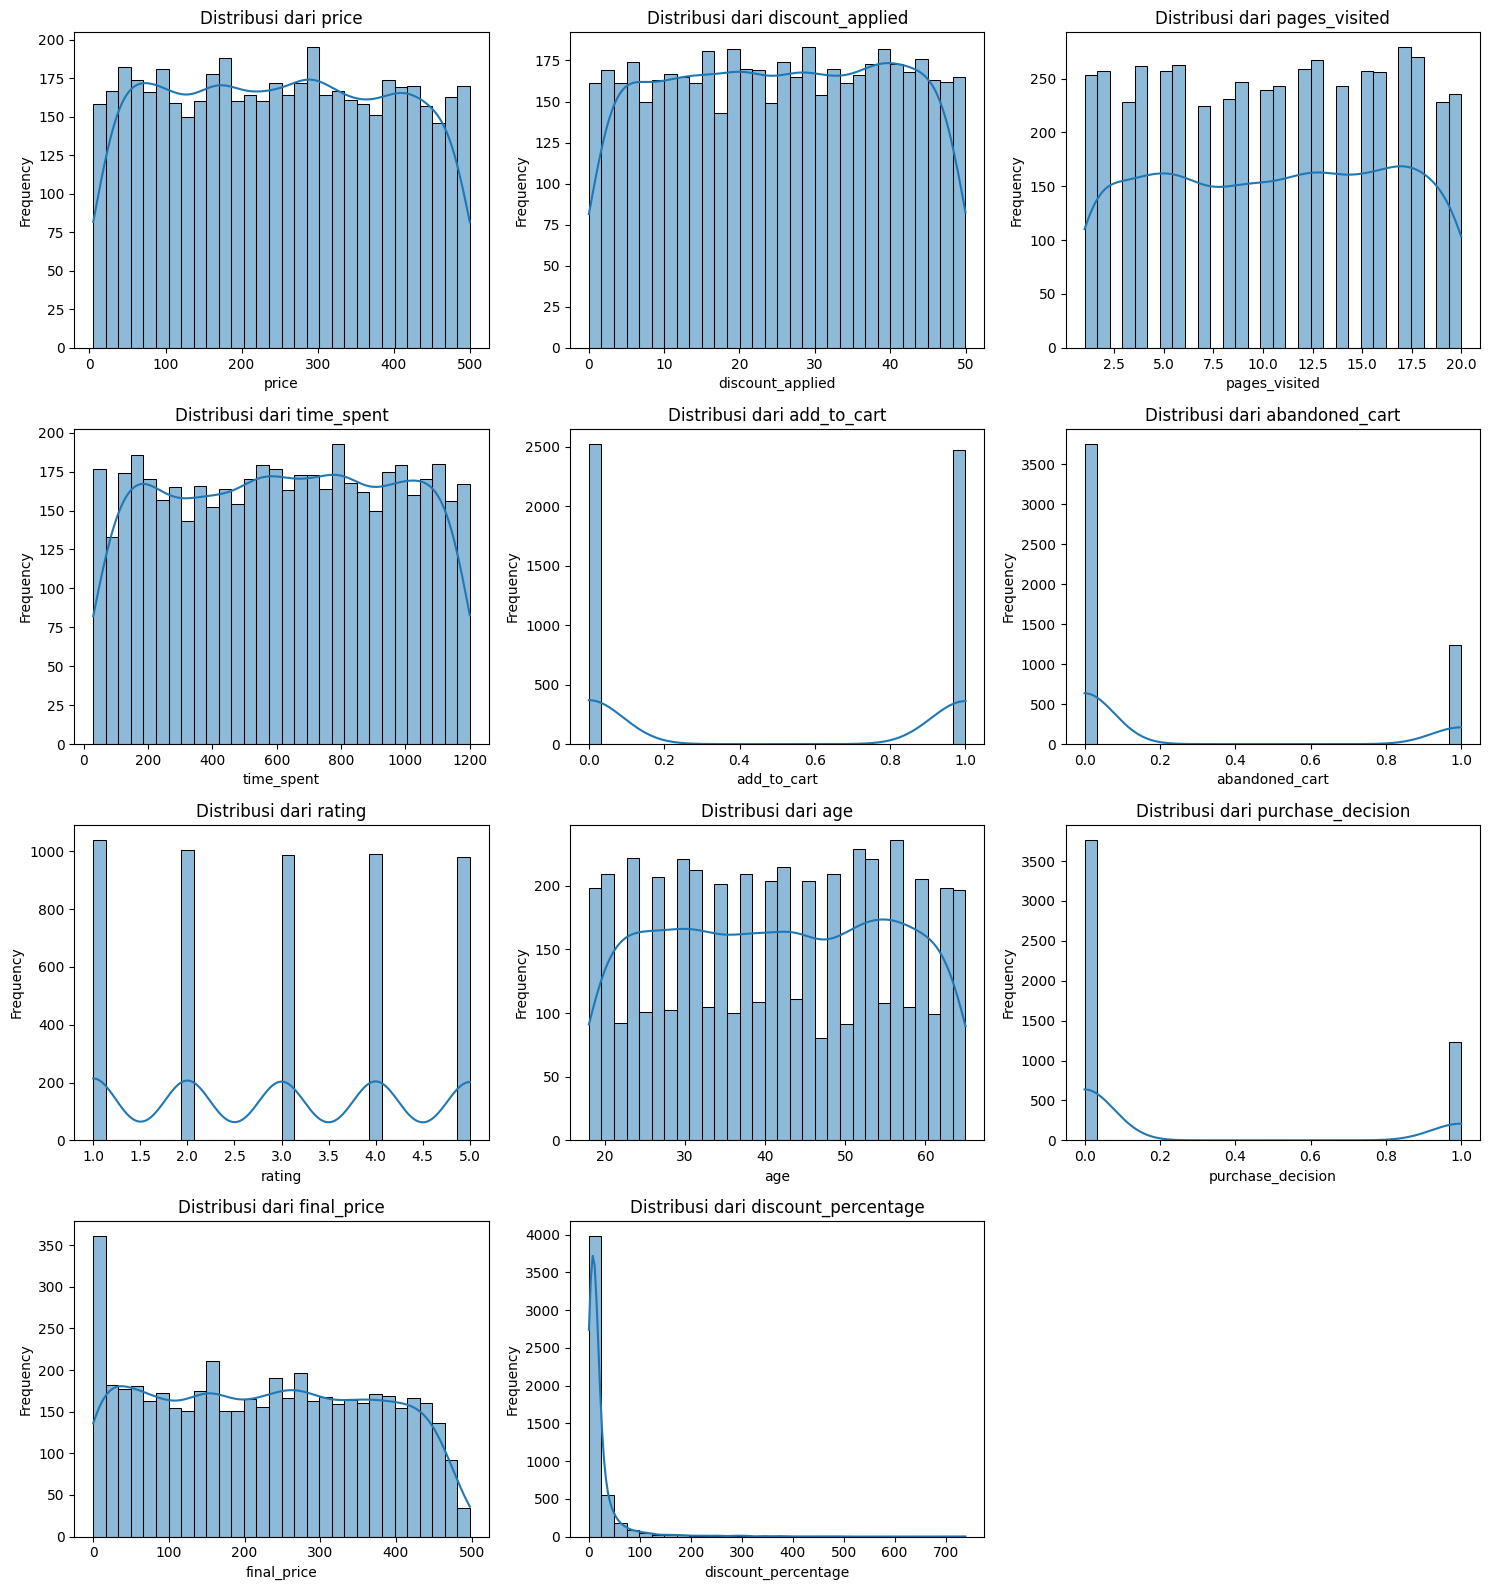

In [19]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribusi dari {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

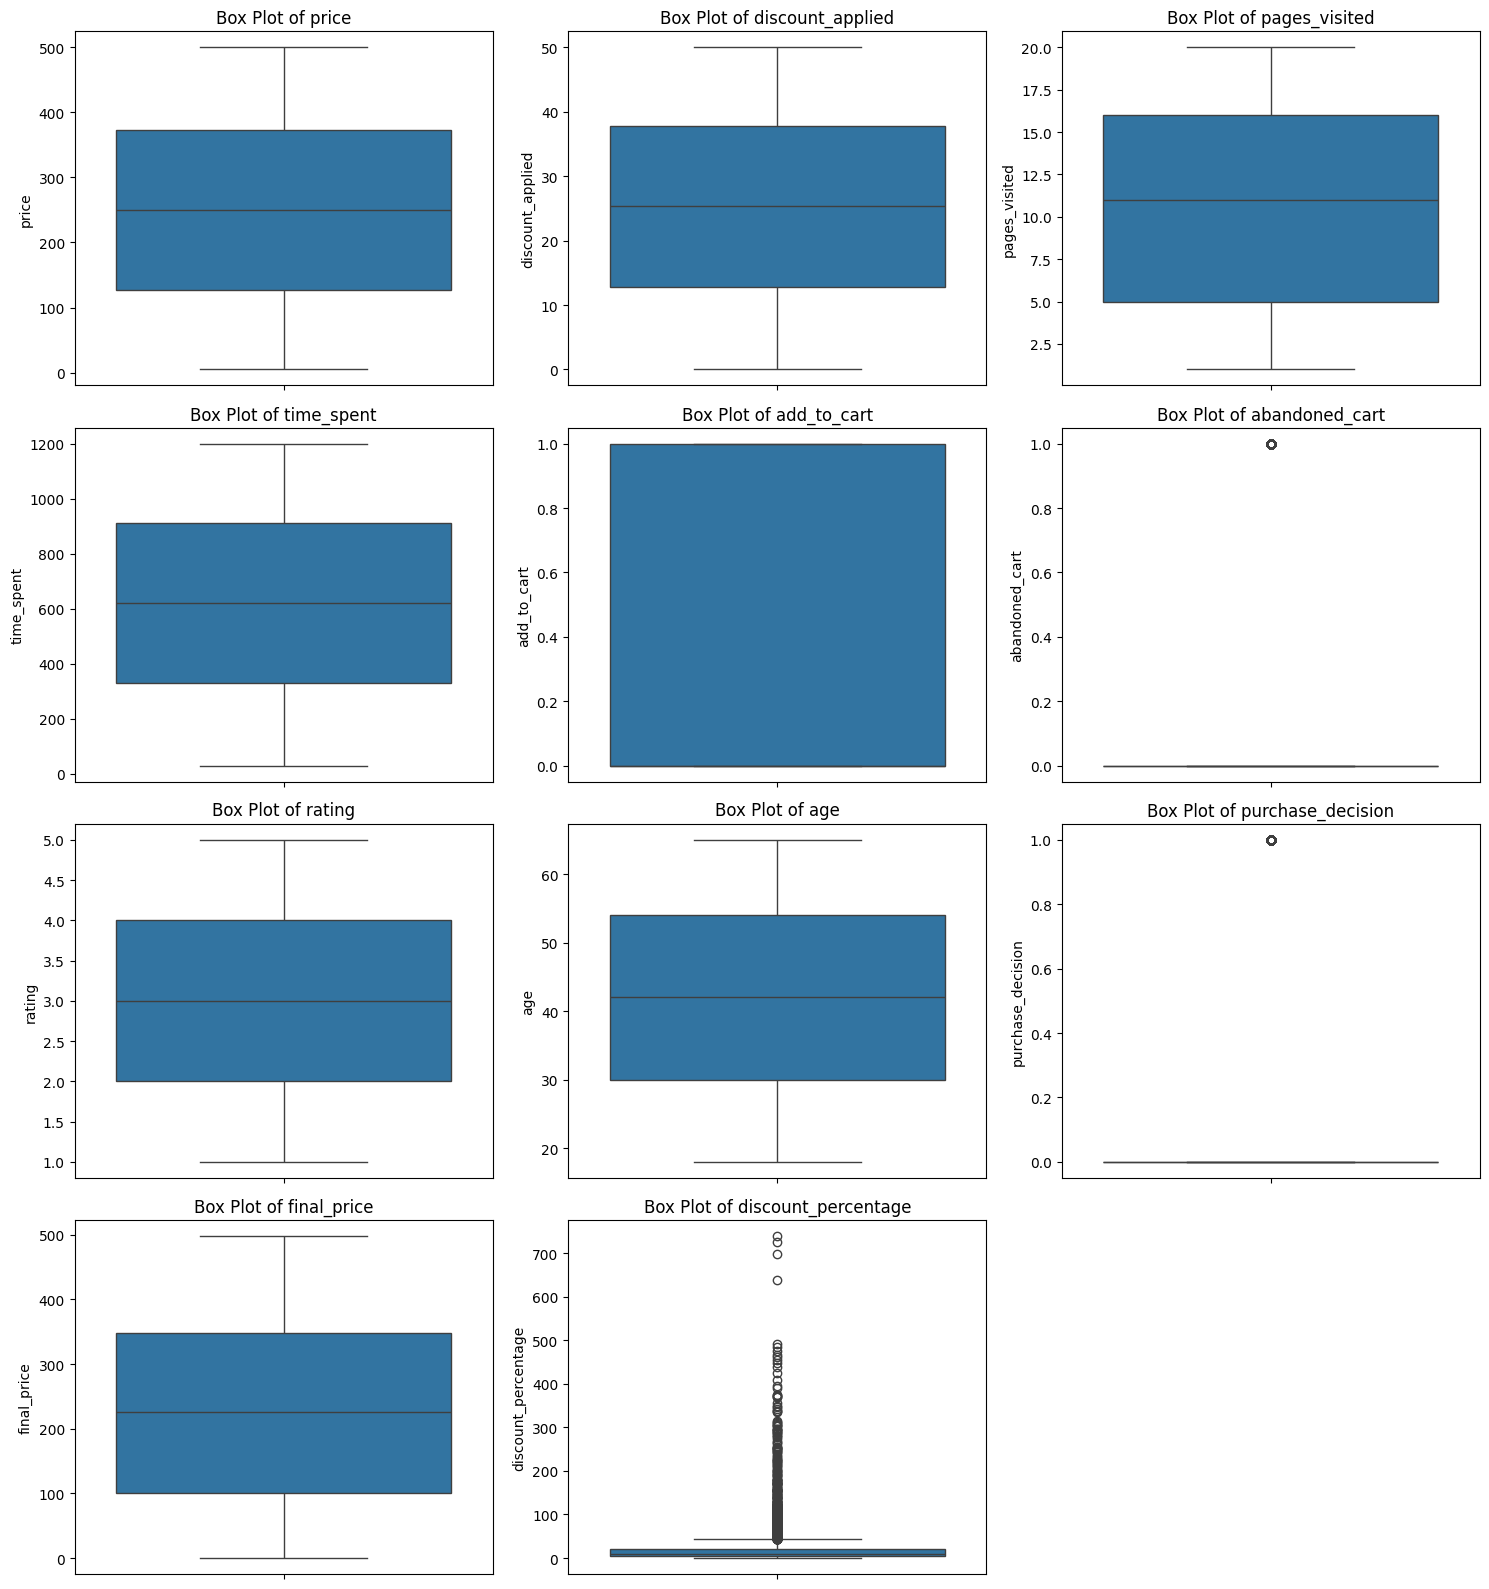

In [20]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='age', ylabel='Count'>

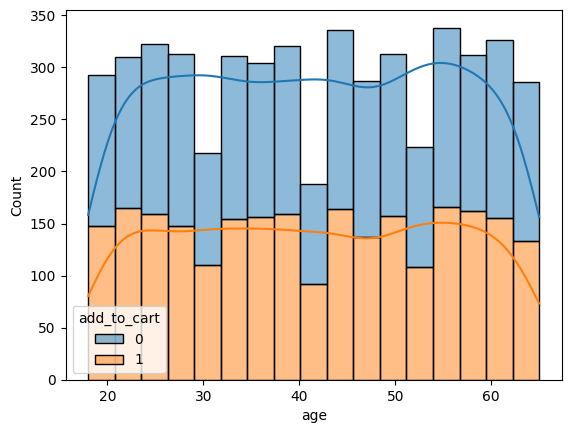

In [21]:
sns.histplot(data=df, x="age", hue="add_to_cart", multiple="stack", kde=True)

<Axes: xlabel='gender', ylabel='Count'>

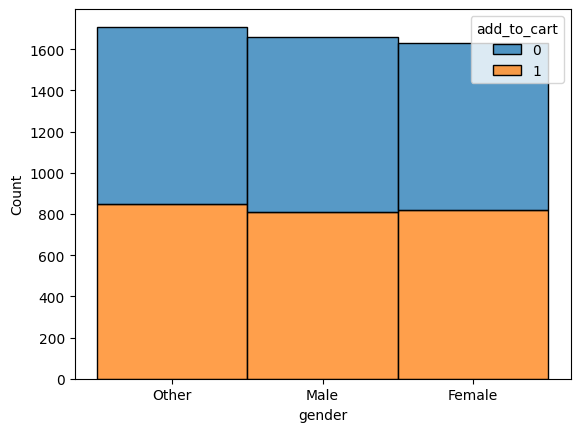

In [22]:
sns.histplot(data=df, x="gender", hue="add_to_cart", multiple="stack")

<Axes: xlabel='age', ylabel='Count'>

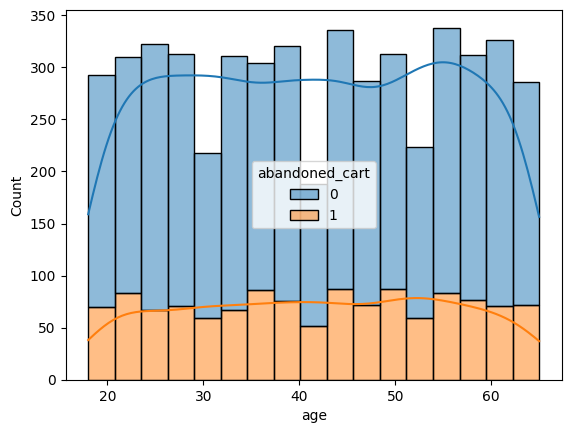

In [23]:
sns.histplot(data=df, x="age", hue="abandoned_cart", multiple="stack", kde=True)

<Axes: xlabel='gender', ylabel='Count'>

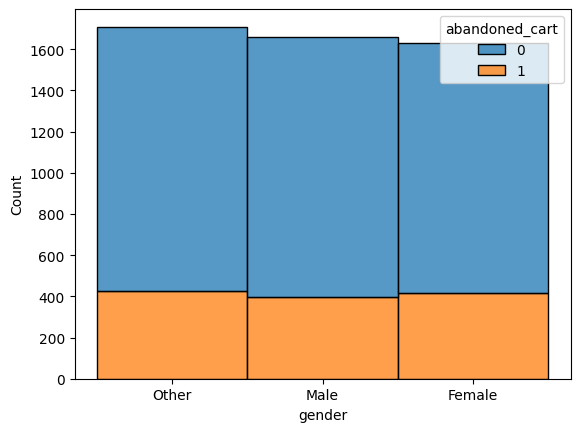

In [24]:
sns.histplot(data=df, x="gender", hue="abandoned_cart", multiple="stack")

<Axes: xlabel='age', ylabel='Count'>

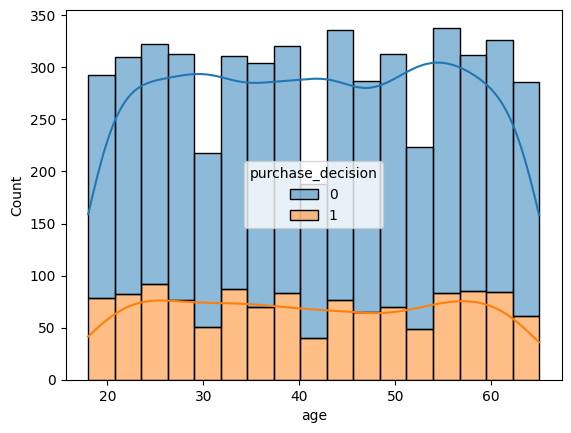

In [25]:
sns.histplot(data=df, x="age", hue="purchase_decision", multiple="stack", kde=True)

<Axes: xlabel='gender', ylabel='Count'>

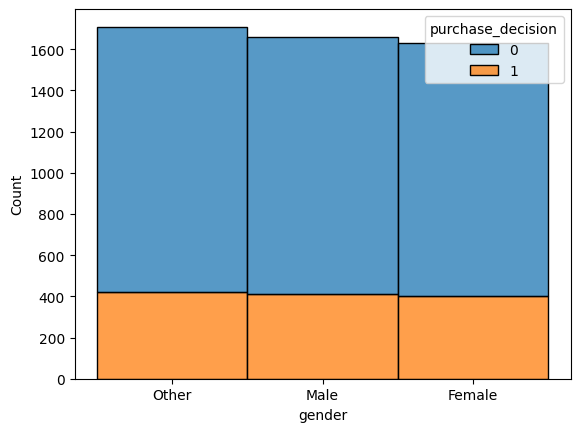

In [26]:
sns.histplot(data=df, x="gender", hue="purchase_decision", multiple="stack")

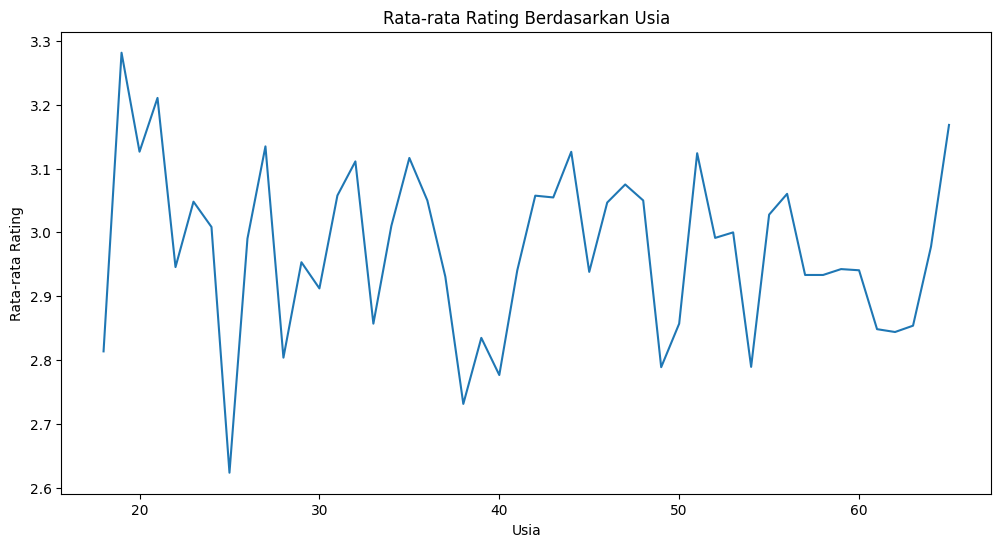

In [27]:
plt.figure(figsize=(12, 6))
avg_rating_by_age = df.groupby('age')['rating'].mean().reset_index()
sns.lineplot(data=avg_rating_by_age, x='age', y='rating')
plt.title('Rata-rata Rating Berdasarkan Usia')
plt.xlabel('Usia')
plt.ylabel('Rata-rata Rating')
plt.show()

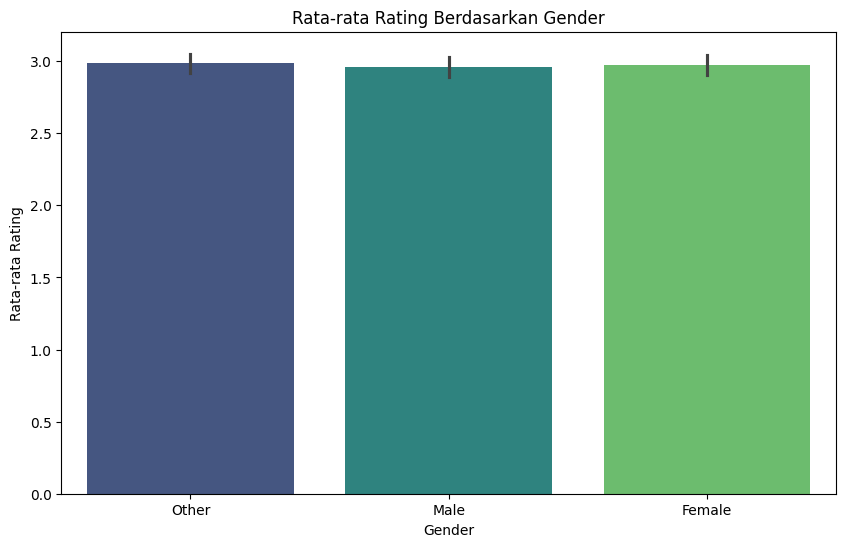

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='gender', y='rating', hue='gender', palette='viridis', legend=False, estimator=lambda x: sum(x)/len(x))
plt.title('Rata-rata Rating Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Rata-rata Rating')
plt.show()

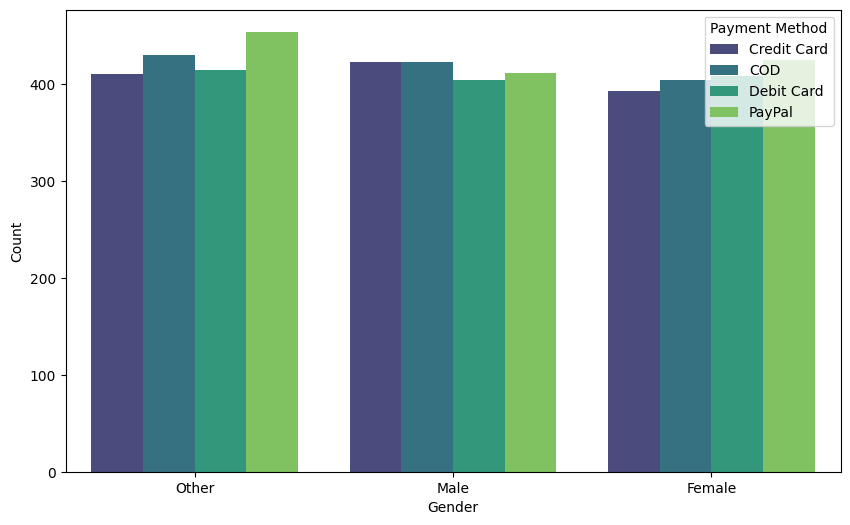

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='gender', hue='payment_method', palette='viridis')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Payment Method')
plt.show()

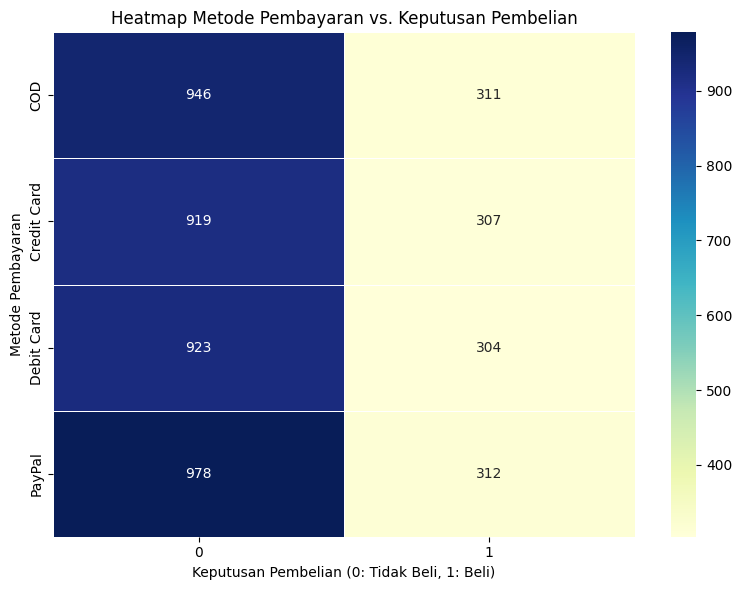

In [30]:
contingency_table = pd.crosstab(df['payment_method'], df['purchase_decision'])

plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap Metode Pembayaran vs. Keputusan Pembelian')
plt.xlabel('Keputusan Pembelian (0: Tidak Beli, 1: Beli)')
plt.ylabel('Metode Pembayaran')
plt.tight_layout()
plt.show()

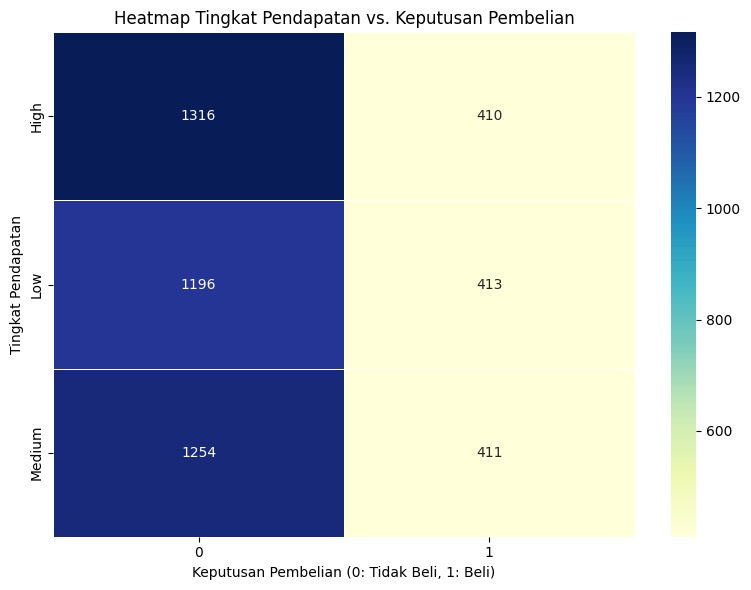

In [31]:
contingency_table_income = pd.crosstab(df['income_level'], df['purchase_decision'])

plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table_income, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap Tingkat Pendapatan vs. Keputusan Pembelian')
plt.xlabel('Keputusan Pembelian (0: Tidak Beli, 1: Beli)')
plt.ylabel('Tingkat Pendapatan')
plt.tight_layout()
plt.show()

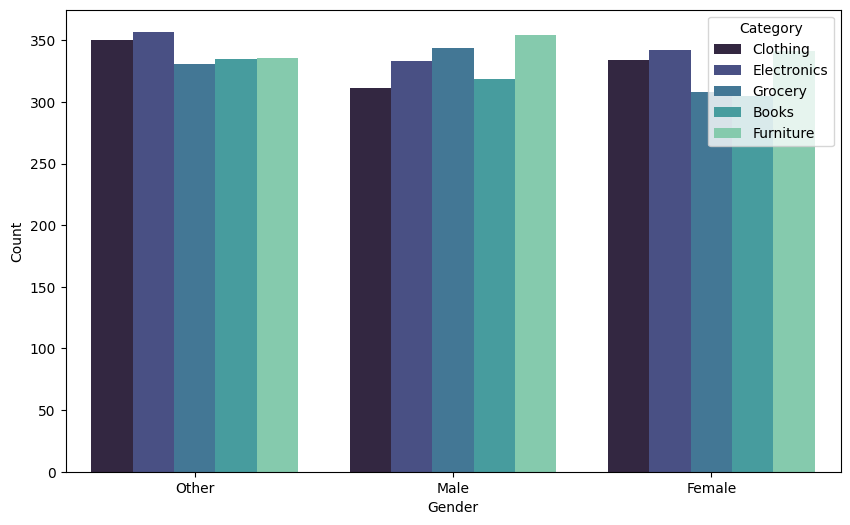

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='gender', hue='category', palette='mako')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Category')
plt.show()

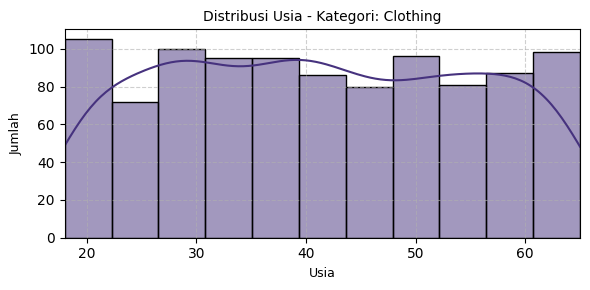

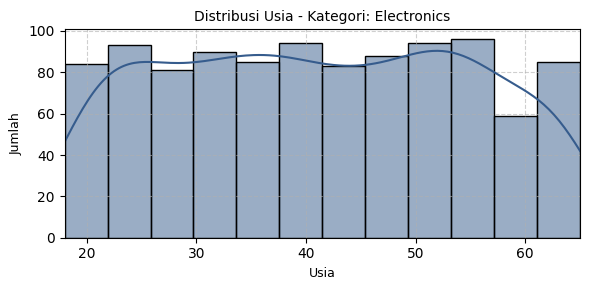

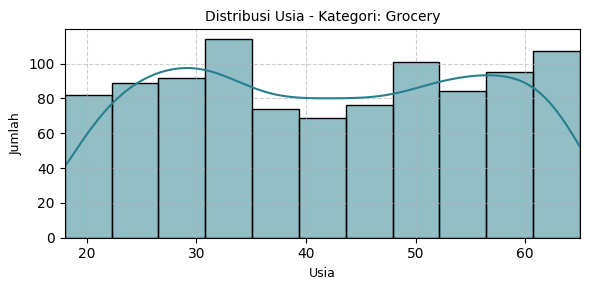

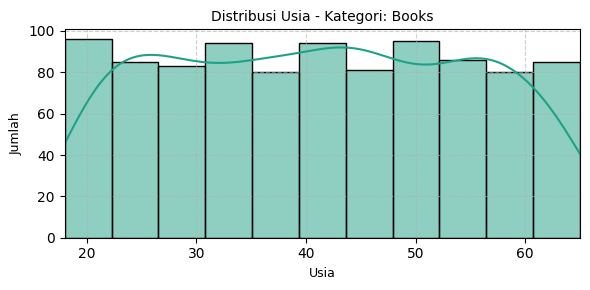

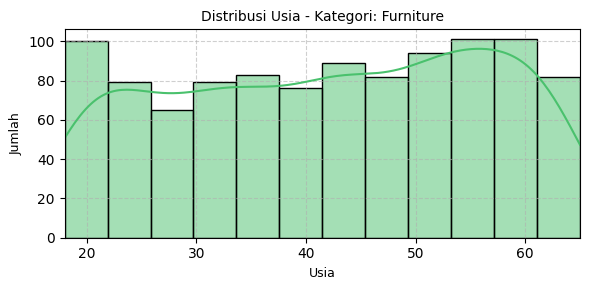

In [33]:
categories = df['category'].unique()
min_age = df['age'].min()
max_age = df['age'].max()

for cat in categories:
    plt.figure(figsize=(6, 3))
    data_cat = df[df['category'] == cat]

    sns.histplot(
        data=data_cat,
        x='age',
        kde=True,
        color=sns.color_palette('viridis')[list(categories).index(cat)],
        bins='auto'
    )

    plt.title(f"Distribusi Usia - Kategori: {cat}", size=10)
    plt.xlabel("Usia", size=9)
    plt.ylabel("Jumlah", size=9)
    plt.xlim(min_age, max_age)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

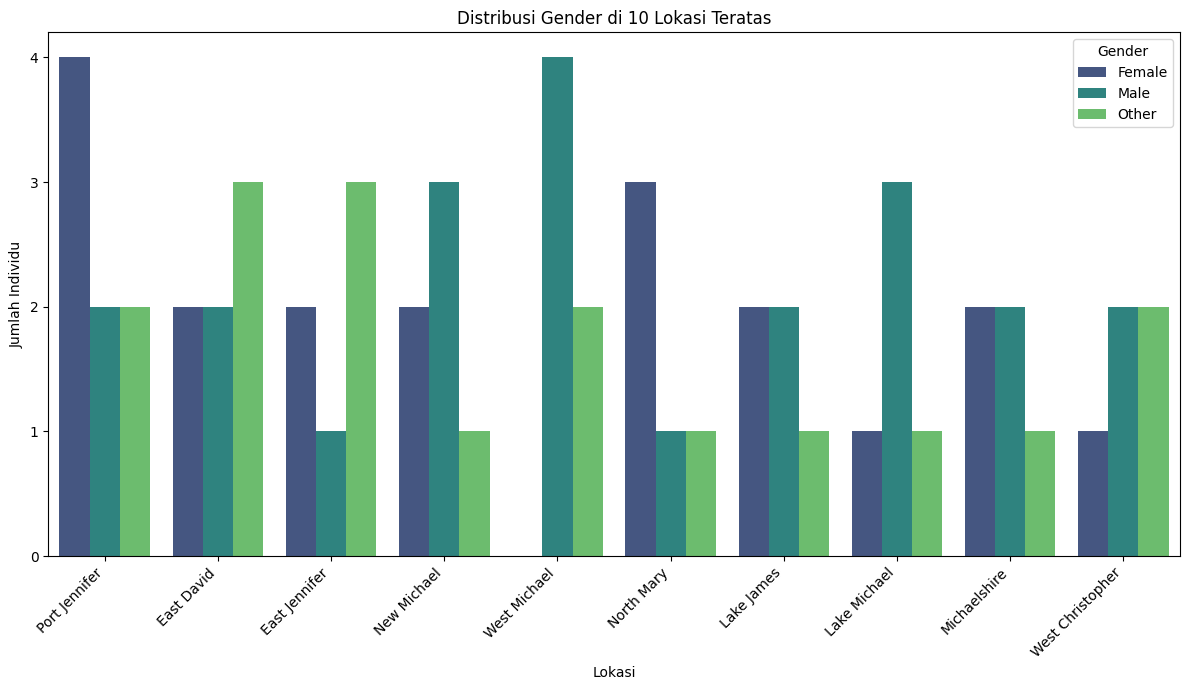

In [34]:
contingency_table_all = pd.crosstab(df['location'], df['gender'])
location_counts = contingency_table_all.sum(axis=1).sort_values(ascending=False)
top_10_locations = location_counts.head(10).index
contingency_table_top_10 = contingency_table_all.loc[top_10_locations]
df_top_10_melted = contingency_table_top_10.reset_index().melt(id_vars='location', var_name='gender', value_name='count')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_top_10_melted, x='location', y='count', hue='gender', palette='viridis')
plt.title('Distribusi Gender di 10 Lokasi Teratas')
plt.xlabel('Lokasi')
plt.ylabel('Jumlah Individu')
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(0, df_top_10_melted['count'].max() + 1, 1))
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [35]:
display(contingency_table_top_10)

gender,Female,Male,Other
location,,,
Port Jennifer,4,2,2
East David,2,2,3
East Jennifer,2,1,3
New Michael,2,3,1
West Michael,0,4,2
North Mary,3,1,1
Lake James,2,2,1
Lake Michael,1,3,1
Michaelshire,2,2,1


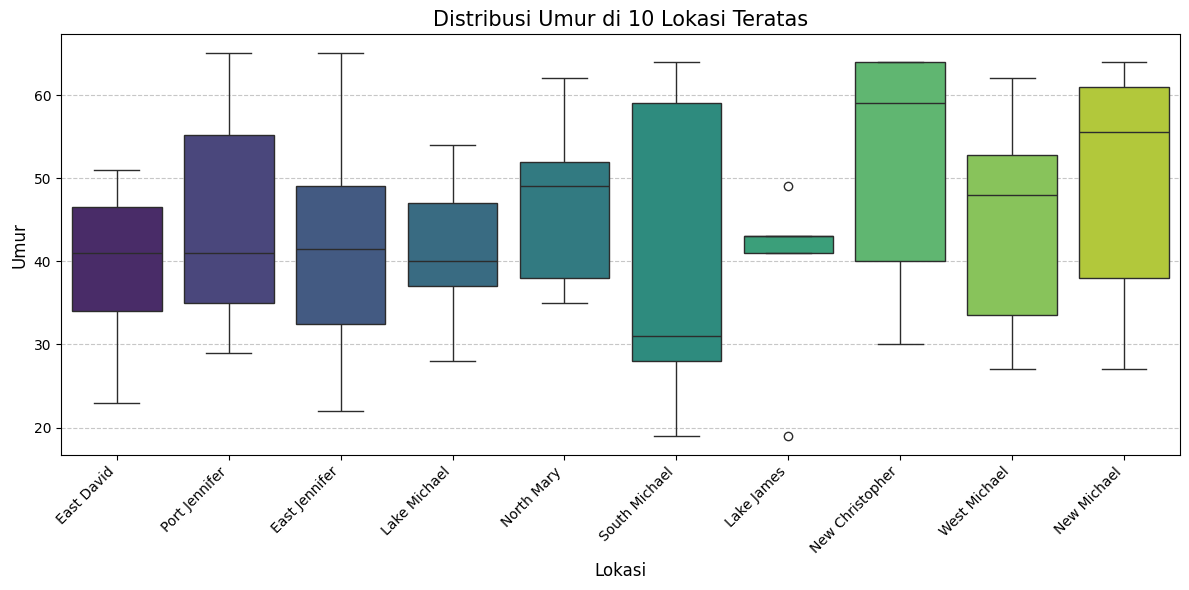

Statistik Umur di 10 Lokasi Teratas:


,mean,median,min,max
location,,,,
East David,39.428571,41.0,23,51
East Jennifer,41.833333,41.5,22,65
Lake James,39.000000,43.0,19,49
Lake Michael,41.200000,40.0,28,54
New Christopher,51.400000,59.0,30,64
New Michael,49.500000,55.5,27,64
North Mary,47.200000,49.0,35,62
Port Jennifer,44.875000,41.0,29,65
South Michael,40.200000,31.0,19,64


In [36]:
top_10_loc_names = df['location'].value_counts().head(10).index
df_top_10 = df[df['location'].isin(top_10_loc_names)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_10, x='location', y='age', palette='viridis', hue='location', legend=False)

plt.title('Distribusi Umur di 10 Lokasi Teratas', size=15)
plt.xlabel('Lokasi', size=12)
plt.ylabel('Umur', size=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Statistik Umur di 10 Lokasi Teratas:")
display(df_top_10.groupby('location')['age'].agg(['mean', 'median', 'min', 'max']))

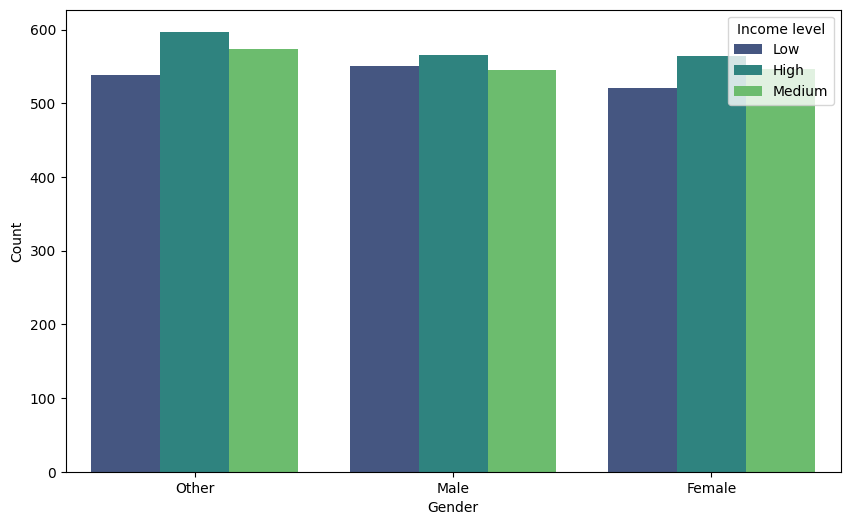

In [37]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='gender', hue='income_level', palette='viridis')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Income level')
plt.show()

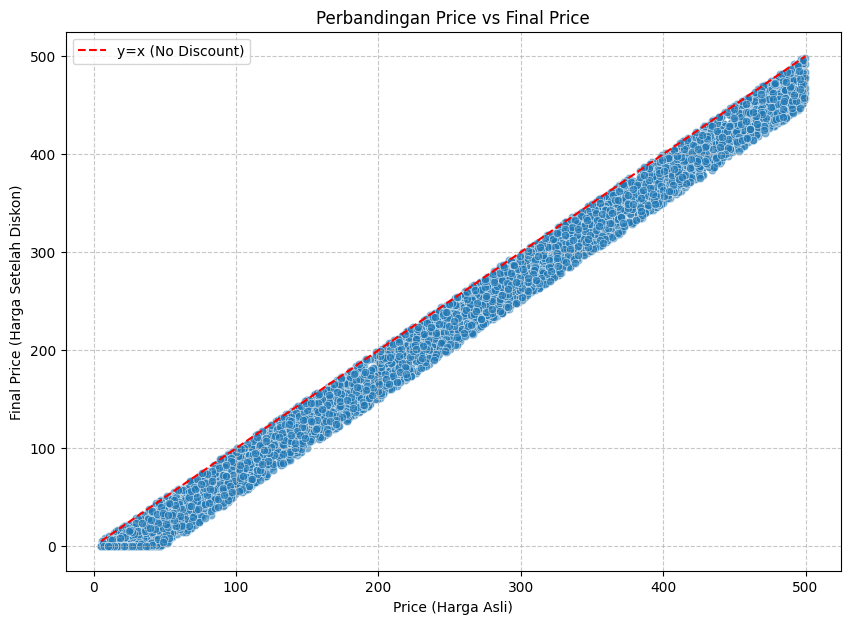

In [38]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='price', y='final_price', alpha=0.6)
plt.plot([df['price'].min(), df['price'].max()], [df['price'].min(), df['price'].max()], color='red', linestyle='--', label='y=x (No Discount)')
plt.title('Perbandingan Price vs Final Price')
plt.xlabel('Price (Harga Asli)')
plt.ylabel('Final Price (Harga Setelah Diskon)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

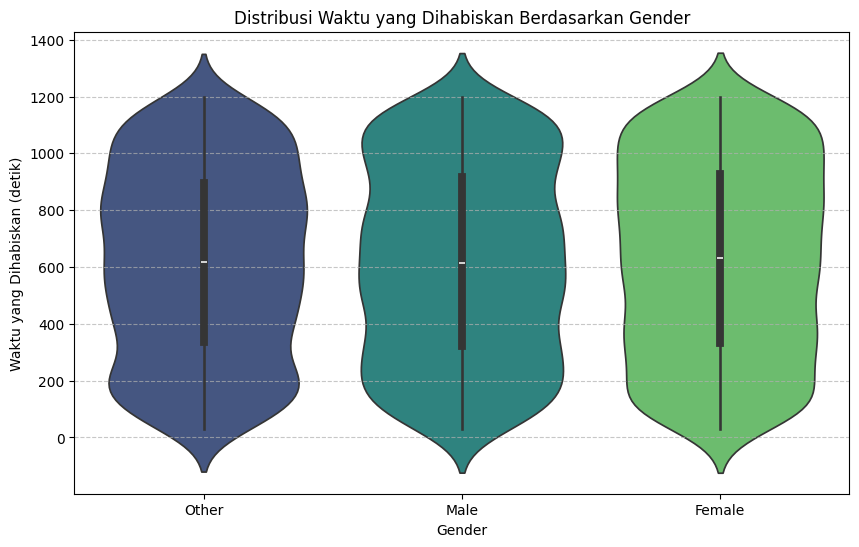

In [39]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='gender', y='time_spent', hue='gender', palette='viridis', legend=False)
plt.title('Distribusi Waktu yang Dihabiskan Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Waktu yang Dihabiskan (detik)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

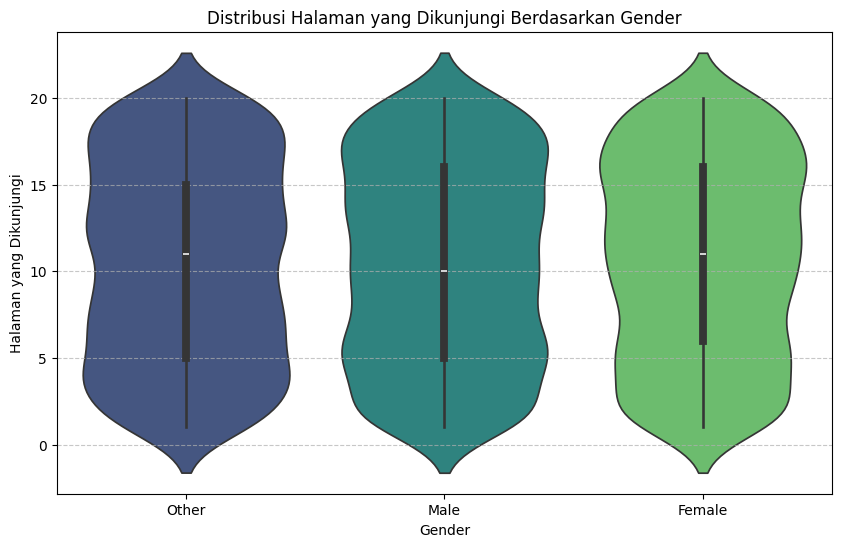

In [40]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='gender', y='pages_visited', hue='gender', palette='viridis', legend=False)
plt.title('Distribusi Halaman yang Dikunjungi Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Halaman yang Dikunjungi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

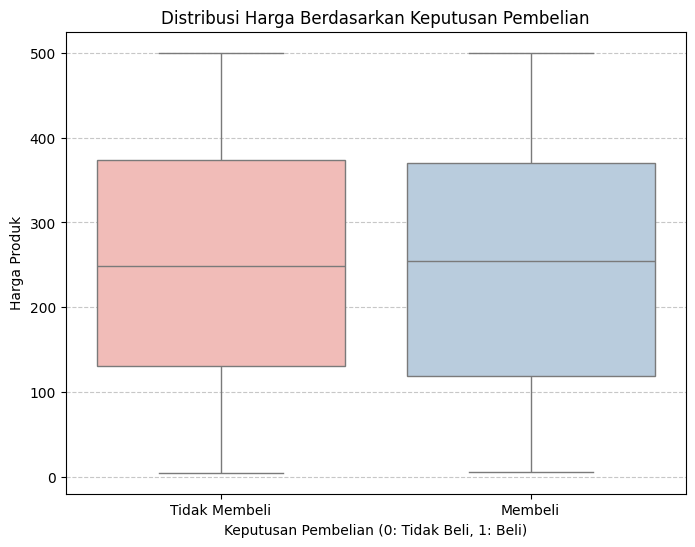

In [41]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='purchase_decision', y='price', hue='purchase_decision', palette='Pastel1', legend=False)
plt.title('Distribusi Harga Berdasarkan Keputusan Pembelian')
plt.xlabel('Keputusan Pembelian (0: Tidak Beli, 1: Beli)')
plt.ylabel('Harga Produk')
plt.xticks([0, 1], ['Tidak Membeli', 'Membeli'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

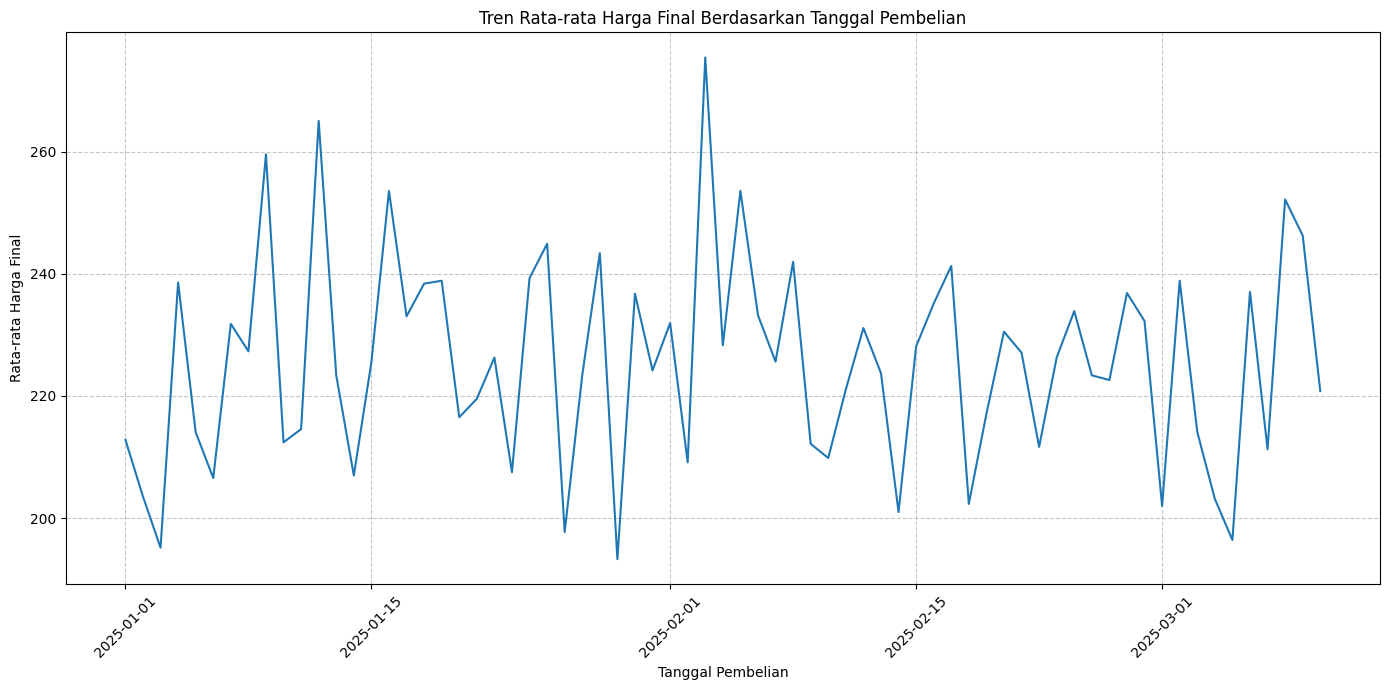

In [42]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['purchase_day'] = df['purchase_date'].dt.date

daily_avg_final_price = df.groupby('purchase_day')['final_price'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_avg_final_price, x='purchase_day', y='final_price')
plt.title('Tren Rata-rata Harga Final Berdasarkan Tanggal Pembelian')
plt.xlabel('Tanggal Pembelian')
plt.ylabel('Rata-rata Harga Final')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

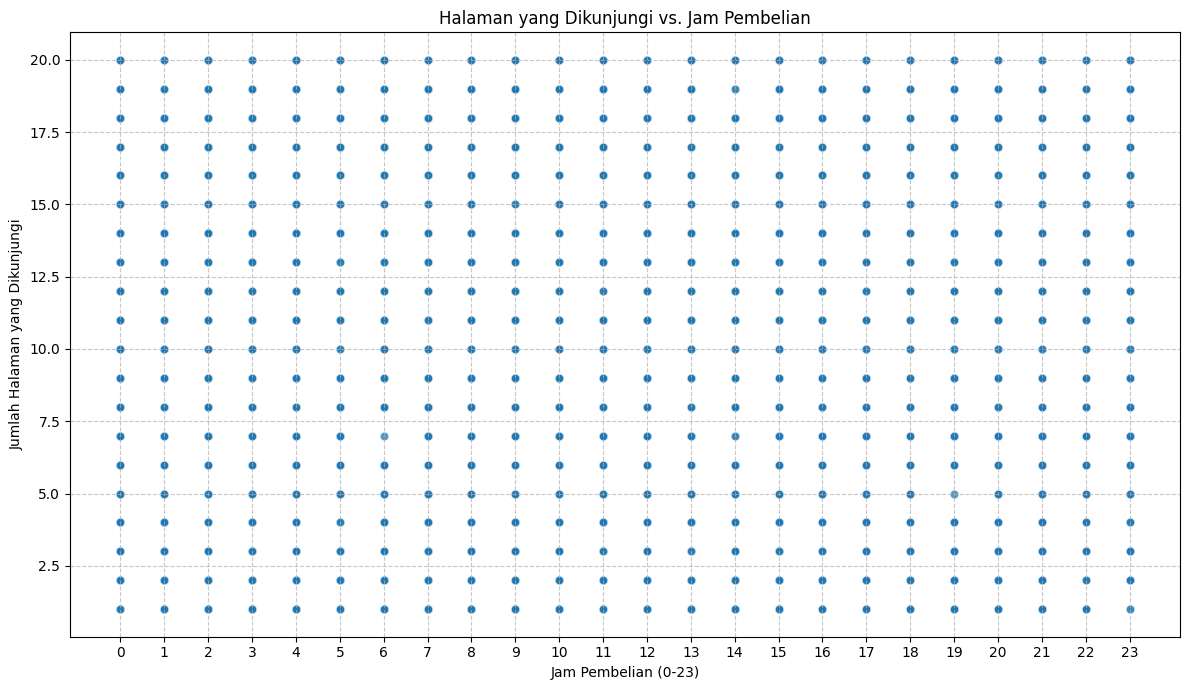

In [43]:
df['purchase_hour'] = df['purchase_date'].dt.hour

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='purchase_hour', y='pages_visited', alpha=0.5)
plt.title('Halaman yang Dikunjungi vs. Jam Pembelian')
plt.xlabel('Jam Pembelian (0-23)')
plt.ylabel('Jumlah Halaman yang Dikunjungi')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

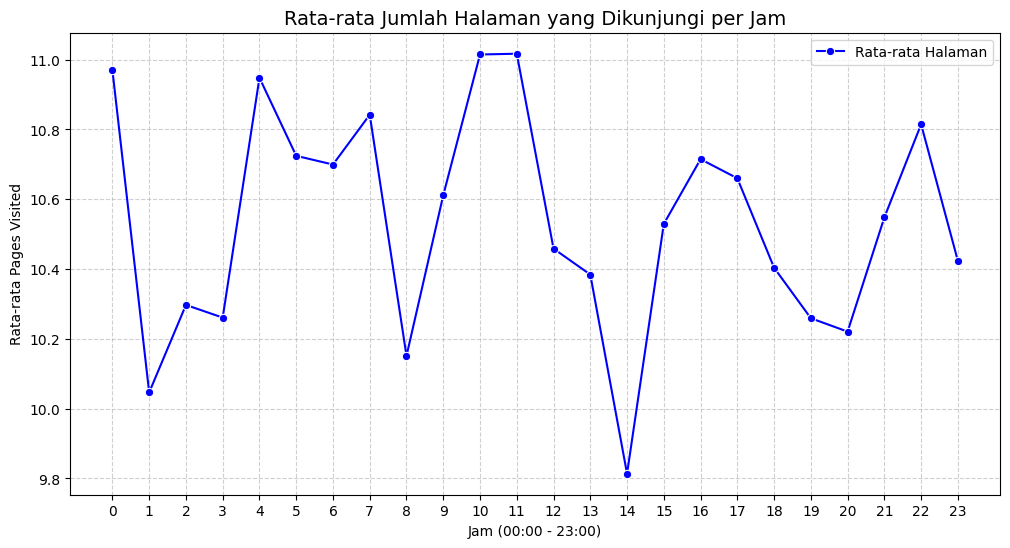

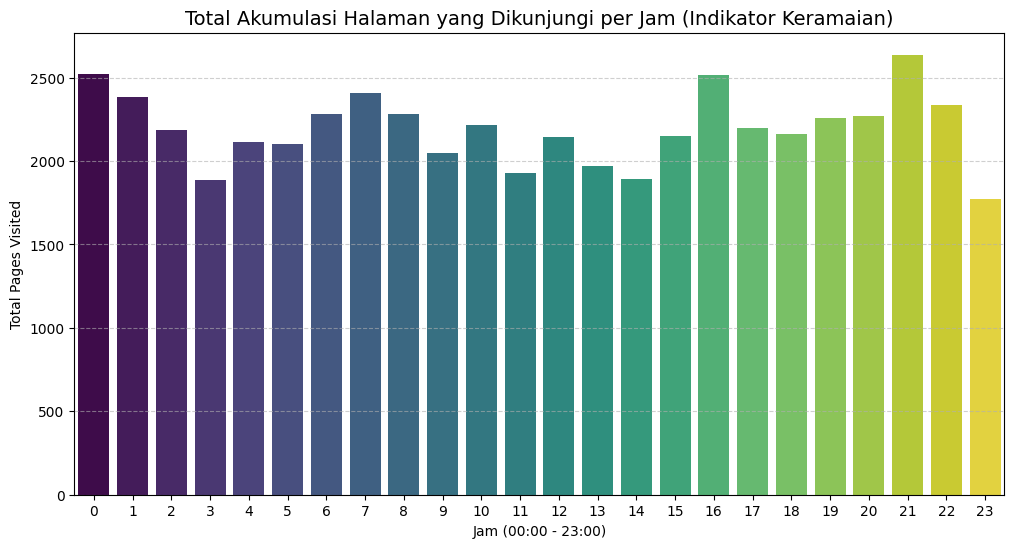

In [44]:
hourly_activity = df.groupby('purchase_hour')['pages_visited'].agg(['mean', 'sum']).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_activity, x='purchase_hour', y='mean', marker='o', color='b', label='Rata-rata Halaman')
plt.title('Rata-rata Jumlah Halaman yang Dikunjungi per Jam', size=14)
plt.xlabel('Jam (00:00 - 23:00)')
plt.ylabel('Rata-rata Pages Visited')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_activity, x='purchase_hour', y='sum', palette='viridis', hue='purchase_hour', legend=False)
plt.title('Total Akumulasi Halaman yang Dikunjungi per Jam (Indikator Keramaian)', size=14)
plt.xlabel('Jam (00:00 - 23:00)')
plt.ylabel('Total Pages Visited')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#KPIs

In [48]:
total_sales = df['final_price'].sum()
print(f"Total Penjualan: {total_sales:,.2f}")

Total Penjualan: 1,130,034.14


In [49]:
df_valid_price = df[df['price'] > 0]
if not df_valid_price.empty:
    average_discount_rate = (df_valid_price['discount_applied'] / df_valid_price['price']).mean() * 100
    print(f"Rata-rata Tingkat Diskon: {average_discount_rate:.2f}%")
else:
    print("Tidak ada produk dengan harga positif untuk menghitung rata-rata tingkat diskon.")

Rata-rata Tingkat Diskon: 22.74%


In [50]:
purchase_conversion_rate = (df['purchase_decision'].sum() / len(df)) * 100
print(f"Tingkat Konversi Pembelian: {purchase_conversion_rate:.2f}%")

Tingkat Konversi Pembelian: 24.68%


In [51]:
add_to_cart_count = df['add_to_cart'].sum()
abandoned_cart_count = df['abandoned_cart'].sum()

if add_to_cart_count > 0:
    abandoned_cart_rate = (abandoned_cart_count / add_to_cart_count) * 100
    print(f"Tingkat Keranjang Terabaikan: {abandoned_cart_rate:.2f}%")
else:
    print("Tidak ada produk yang ditambahkan ke keranjang, sehingga tingkat keranjang terabaikan tidak dapat dihitung.")

Tingkat Keranjang Terabaikan: 50.10%


In [52]:
average_rating = df['rating'].mean()
print(f"Rata-rata Rating: {average_rating:.2f}")

Rata-rata Rating: 2.97


In [53]:
average_time_spent = df['time_spent'].mean()
print(f"Rata-rata Waktu yang Dihabiskan: {average_time_spent:.2f} detik")

Rata-rata Waktu yang Dihabiskan: 618.66 detik


In [54]:
average_pages_visited = df['pages_visited'].mean()
print(f"Rata-rata Halaman yang Dikunjungi: {average_pages_visited:.2f}")

Rata-rata Halaman yang Dikunjungi: 10.53


## Feature Engineering

In [61]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['day_of_week'] = df['purchase_date'].dt.dayofweek
df['month'] = df['purchase_date'].dt.month
df['is_weekend'] = df['purchase_date'].dt.dayofweek.isin([5, 6]).astype(int)

display(df[['purchase_date', 'day_of_week', 'month', 'is_weekend']].head())
display(df[['purchase_date', 'day_of_week', 'month', 'is_weekend']].describe())

,purchase_date,day_of_week,month,is_weekend
0,2025-01-31 04:07:28,4,1,0
1,2025-01-21 06:07:28,1,1,0
2,2025-02-05 00:30:15,2,2,0
3,2025-01-08 16:03:46,2,1,0
4,2025-02-27 19:53:59,3,2,0


,purchase_date,day_of_week,month,is_weekend
count,5000,5000.0000,5000.000000,5000.00000
mean,2025-02-03 14:37:54.261199872,3.0846,1.665000,0.29740
min,2025-01-01 00:33:33,0.0000,1.000000,0.00000
25%,2025-01-17 15:08:00.500000,1.0000,1.000000,0.00000
50%,2025-02-03 01:44:04.500000,3.0000,2.000000,0.00000
75%,2025-02-20 17:18:48,5.0000,2.000000,1.00000
max,2025-03-10 10:56:21,6.0000,3.000000,1.00000
std,NaN,1.9848,0.698049,0.45716


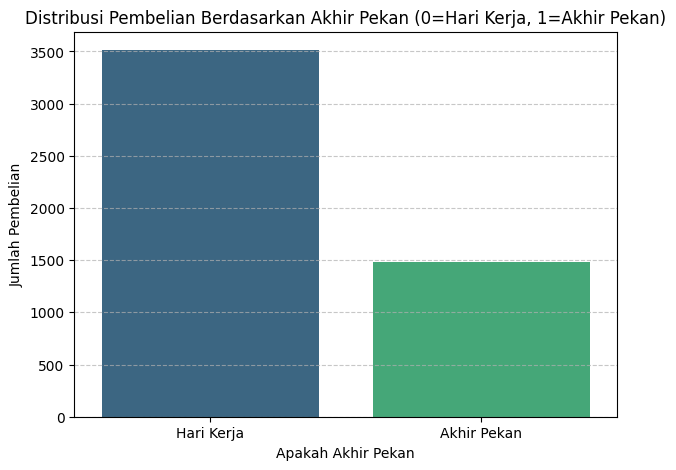

In [70]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='is_weekend', hue='is_weekend', palette='viridis', legend=False)
plt.title('Distribusi Pembelian Berdasarkan Akhir Pekan (0=Hari Kerja, 1=Akhir Pekan)')
plt.xlabel('Apakah Akhir Pekan')
plt.ylabel('Jumlah Pembelian')
plt.xticks(ticks=[0, 1], labels=['Hari Kerja', 'Akhir Pekan'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [64]:
df['price_range'] = pd.cut(df['price'],
                             bins=[0, 150, 300, np.inf],
                             labels=['Low', 'Medium', 'High'],
                             right=False)

display(df[['price', 'price_range']].head())
display(df['price_range'].value_counts())
display(df['price_range'].describe())

,price,price_range
0,389.23,High
1,344.81,High
2,180.59,Medium
3,415.26,High
4,352.82,High


,count
price_range,
High,1974
Medium,1562
Low,1464


,price_range
count,5000
unique,3
top,High
freq,1974


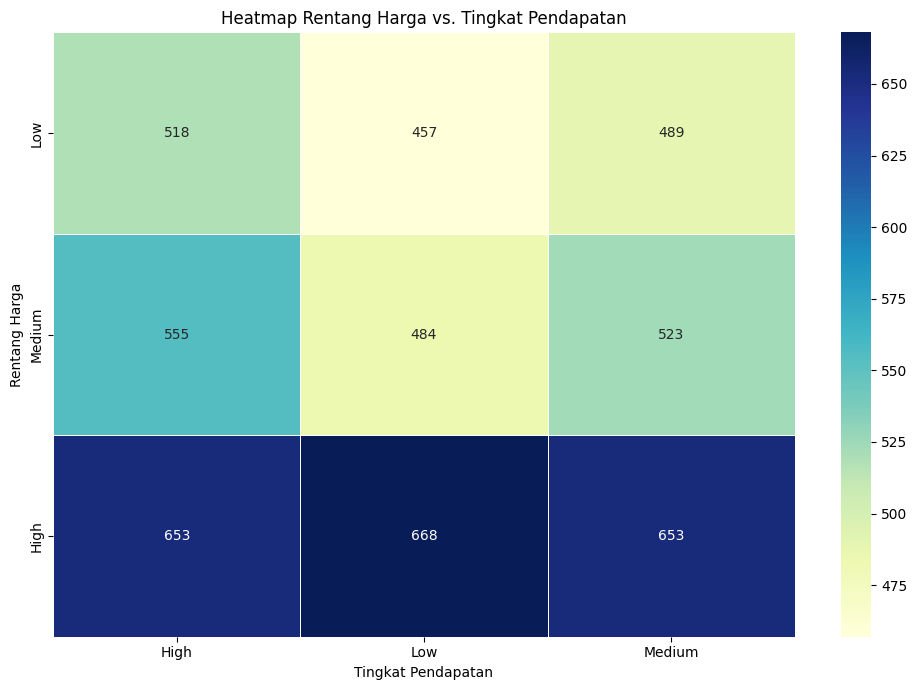

In [71]:
contingency_table_price_income = pd.crosstab(df['price_range'], df['income_level'])

plt.figure(figsize=(10, 7))
sns.heatmap(contingency_table_price_income, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap Rentang Harga vs. Tingkat Pendapatan')
plt.xlabel('Tingkat Pendapatan')
plt.ylabel('Rentang Harga')
plt.tight_layout()
plt.show()

In [65]:
df['avg_time_per_page'] = df.apply(lambda row: row['time_spent'] / row['pages_visited'] if row['pages_visited'] > 0 else 0, axis=1)

display(df[['time_spent', 'pages_visited', 'avg_time_per_page']].head())
display(df['avg_time_per_page'].describe())

,time_spent,pages_visited,avg_time_per_page
0,955,6,159.166667
1,790,8,98.750000
2,336,3,112.000000
3,624,4,156.000000
4,579,4,144.750000


,avg_time_per_page
count,5000.000000
mean,110.323836
std,161.670068
min,1.550000
25%,30.761905
50%,59.324561
75%,115.000000
max,1193.000000


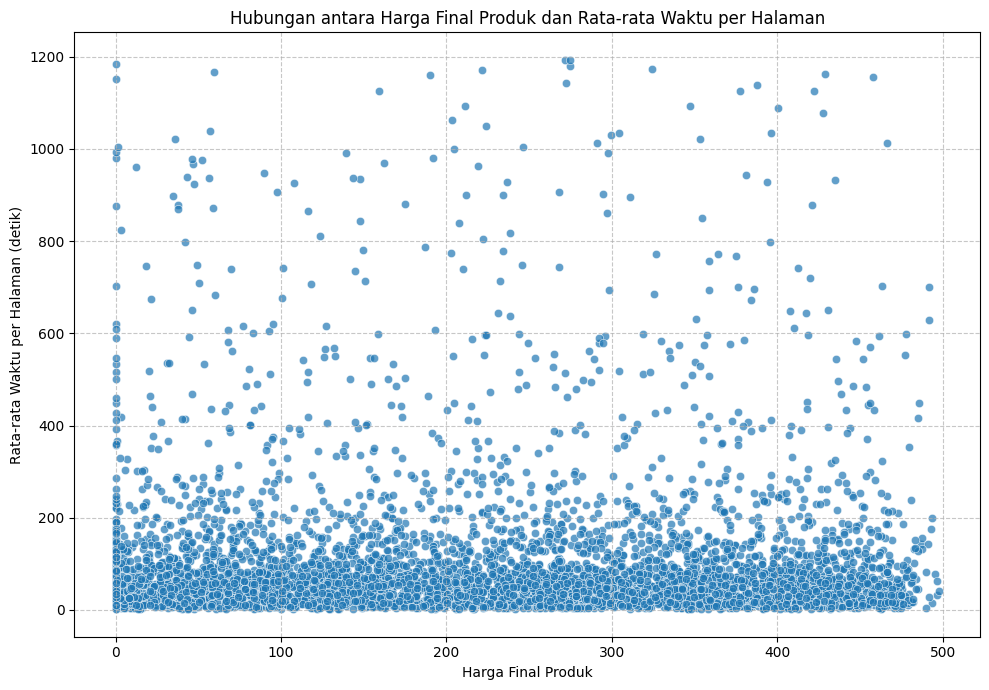

In [75]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='final_price', y='avg_time_per_page', alpha=0.7)
plt.title('Hubungan antara Harga Final Produk dan Rata-rata Waktu per Halaman')
plt.xlabel('Harga Final Produk')
plt.ylabel('Rata-rata Waktu per Halaman (detik)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

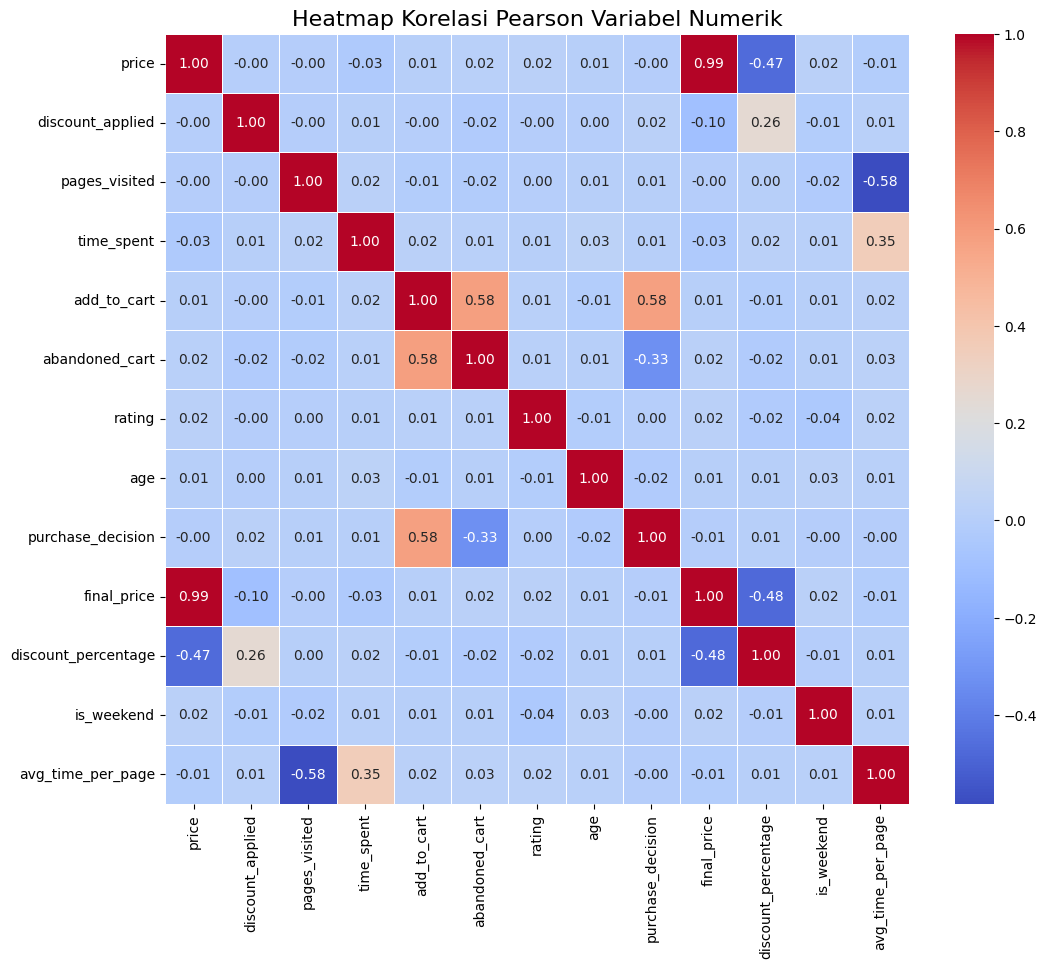

In [76]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Pearson Variabel Numerik', size=16)
plt.show()

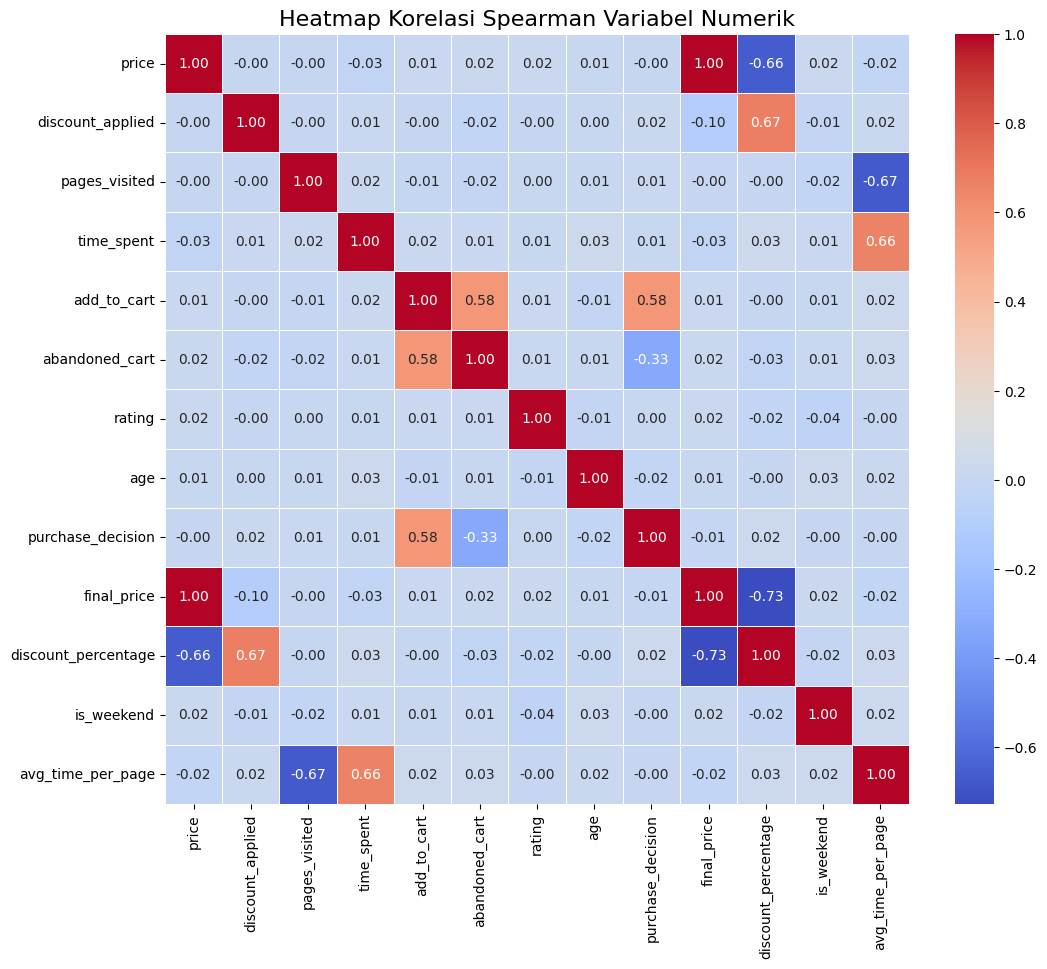

In [77]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
spearman_corr_matrix = numeric_df.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Spearman Variabel Numerik', size=16)
plt.show()

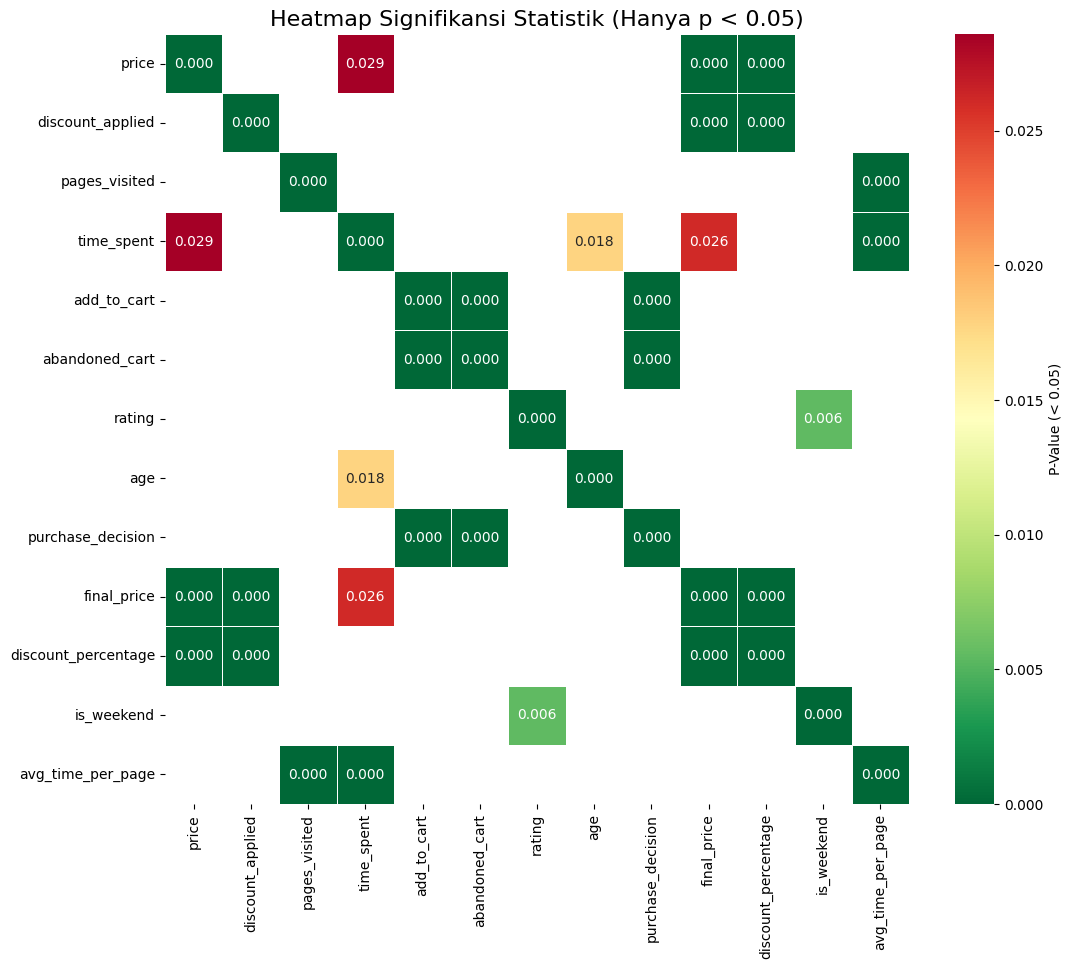

Daftar Korelasi yang Signifikan Secara Statistik (Alpha = 0.05):
* price & time_spent | p-value: 0.0286
* price & final_price | p-value: 0.0000
* price & discount_percentage | p-value: 0.0000
* discount_applied & final_price | p-value: 0.0000
* discount_applied & discount_percentage | p-value: 0.0000
* pages_visited & avg_time_per_page | p-value: 0.0000
* time_spent & age | p-value: 0.0178
* time_spent & final_price | p-value: 0.0261
* time_spent & avg_time_per_page | p-value: 0.0000
* add_to_cart & abandoned_cart | p-value: 0.0000
* add_to_cart & purchase_decision | p-value: 0.0000
* abandoned_cart & purchase_decision | p-value: 0.0000
* rating & is_weekend | p-value: 0.0056
* final_price & discount_percentage | p-value: 0.0000


In [78]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numeric_cols)

p_values = pd.DataFrame(np.ones((n_cols, n_cols)), columns=numeric_cols, index=numeric_cols)
for col1 in numeric_cols:
    for col2 in numeric_cols:
        if col1 == col2:
            p_values.loc[col1, col2] = 0.0
        else:
            _, p = pearsonr(df[col1], df[col2])
            p_values.loc[col1, col2] = p

plt.figure(figsize=(12, 10))
mask_insignificant = p_values > 0.05

sns.heatmap(p_values,
            annot=True,
            cmap='RdYlGn_r',
            fmt='.3f',
            mask=mask_insignificant,
            linewidths=0.5,
            cbar_kws={'label': 'P-Value (< 0.05)'})

plt.title('Heatmap Signifikansi Statistik (Hanya p < 0.05)', size=16)
plt.show()

print("Daftar Korelasi yang Signifikan Secara Statistik (Alpha = 0.05):")
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        p = p_values.iloc[i, j]
        if p < 0.05:
            print(f"* {numeric_cols[i]} & {numeric_cols[j]} | p-value: {p:.4f}")